# Covid-19 in South Korea

- To which region side of Seoul did virus spread the fastest and what might impacted it?
- Is treatment at home is effective as in hospital?
- In average how many people is infected by one person?

## Dataset import (format: alt + shift + F)

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.dates import MonthLocator
import seaborn as sns
from functions_sandbox import cleaner
from scipy import stats

path = r"D:\IT_projects\Turing_Colledge\Modul1\Sprint4\project"

case = pd.read_csv(path + r"\Case.csv")
patient_info = pd.read_csv(path + r"\PatientInfo.csv")
policy = pd.read_csv(path + r"\Policy.csv")
region = pd.read_csv(path + r"\Region.csv")
search_trend = pd.read_csv(path + r"\SearchTrend.csv")
seoul_floating = pd.read_csv(path + r"\SeoulFloating.csv")
time = pd.read_csv(path + r"\Time.csv")
time_age = pd.read_csv(path + r"\TimeAge.csv")
time_gender = pd.read_csv(path + r"\TimeGender.csv")
time_province = pd.read_csv(path + r"\TimeProvince.csv")
weather = pd.read_csv(path + r"\Weather.csv")

all_tables = [
    {"case": case},
    {"patient_info": patient_info},
    {"policy": policy},
    {"region": region},
    {"search_trend": search_trend},
    {"seoul_floating": seoul_floating},
    {"time": time},
    {"time_age": time_age},
    {"time_gender": time_gender},
    {"time_province": time_province},
    {"weather": weather},
]

### First look

In [279]:
shape_table = [
    (list(table.keys())[0], list(table.values())[0].shape) for table in all_tables
]
for look in shape_table:
    print(look)

('case', (174, 8))
('patient_info', (5165, 14))
('policy', (61, 7))
('region', (244, 12))
('search_trend', (1642, 5))
('seoul_floating', (1084800, 7))
('time', (163, 7))
('time_age', (1089, 5))
('time_gender', (242, 5))
('time_province', (2771, 6))
('weather', (26271, 10))


In [3]:
weather.head(3)
#case: latitude, longitude to float;
#patient_info: many NaNs in various columns;
#policy: difficult to analise;
#region: very clean to analyse;
#search_trend: wrong dtype for date; nice table to analyse;
#seoul_floating: wrong dtype for date; what is fp_num?, birth_year?;
#time: should time be days?; dtype for date is wrong;
#time_age: wrong dtype for date; strange time; 
#time_gender: dtype for date; looks like random table;
#time_province: dtype for date; decent;
#weather: dtype for date; some of NaNs exists; interesting perspective to analyse;

,code,province,date,avg_temp,min_temp,max_temp,precipitation,max_wind_speed,most_wind_direction,avg_relative_humidity
0,10000,Seoul,2016-01-01,1.2,-3.3,4.0,0.0,3.5,90.0,73.0
1,11000,Busan,2016-01-01,5.3,1.1,10.9,0.0,7.4,340.0,52.1
2,12000,Daegu,2016-01-01,1.7,-4.0,8.0,0.0,3.7,270.0,70.5


In [5]:
time_province.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2771 entries, 0 to 2770
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   date       2771 non-null   object
 1   time       2771 non-null   int64 
 2   province   2771 non-null   object
 3   confirmed  2771 non-null   int64 
 4   released   2771 non-null   int64 
 5   deceased   2771 non-null   int64 
dtypes: int64(4), object(2)
memory usage: 130.0+ KB


### TimeProvince data preparation/cleaning

In [6]:
clean_time_province = cleaner(time_province, info=False)
clean_time_province["date"] = pd.to_datetime(clean_time_province["date"])
clean_time_province.sort_values(by="date", ascending=True, inplace=True)
clean_time_province.head(5)

,date,time,province,confirmed,released,deceased
0,2020-01-20,16,Seoul,0,0,0
16,2020-01-20,16,Jeju-do,0,0,0
15,2020-01-20,16,Gyeongsangnam-do,0,0,0
14,2020-01-20,16,Gyeongsangbuk-do,0,0,0
13,2020-01-20,16,Jeollanam-do,0,0,0


### Region data preparation/cleaning

In [7]:
clean_region = cleaner(region, info=False)
clean_region.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   code                      244 non-null    int64  
 1   province                  244 non-null    object 
 2   city                      244 non-null    object 
 3   latitude                  244 non-null    float64
 4   longitude                 244 non-null    float64
 5   elementary_school_count   244 non-null    int64  
 6   kindergarten_count        244 non-null    int64  
 7   university_count          244 non-null    int64  
 8   academy_ratio             244 non-null    float64
 9   elderly_population_ratio  244 non-null    float64
 10  elderly_alone_ratio       244 non-null    float64
 11  nursing_home_count        244 non-null    int64  
dtypes: float64(5), int64(5), object(2)
memory usage: 23.0+ KB


### Case data preparation/cleaning

In [243]:
clean_case = cleaner(case, info=False)
clean_case.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 174 entries, 0 to 173
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   case_id         174 non-null    int64 
 1   province        174 non-null    object
 2   city            174 non-null    object
 3   group           174 non-null    bool  
 4   infection_case  174 non-null    object
 5   confirmed       174 non-null    int64 
 6   latitude        174 non-null    object
 7   longitude       174 non-null    object
dtypes: bool(1), int64(2), object(5)
memory usage: 9.8+ KB


### Time data preparation/cleaning

In [9]:
clean_time = cleaner(time, info=False)
clean_time.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 163 entries, 0 to 162
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   date       163 non-null    object
 1   time       163 non-null    int64 
 2   test       163 non-null    int64 
 3   negative   163 non-null    int64 
 4   confirmed  163 non-null    int64 
 5   released   163 non-null    int64 
 6   deceased   163 non-null    int64 
dtypes: int64(6), object(1)
memory usage: 9.0+ KB


In [10]:
clean_time["date"] = pd.to_datetime(clean_time["date"])
clean_time.sort_values(by="date", ascending=True, inplace=True)
clean_time

,date,time,test,negative,confirmed,released,deceased
0,2020-01-20,16,1,0,1,0,0
1,2020-01-21,16,1,0,1,0,0
2,2020-01-22,16,4,3,1,0,0
3,2020-01-23,16,22,21,1,0,0
4,2020-01-24,16,27,25,2,0,0
...,...,...,...,...,...,...,...
158,2020-06-26,0,1232315,1200885,12602,11172,282
159,2020-06-27,0,1243780,1211261,12653,11317,282
160,2020-06-28,0,1251695,1219975,12715,11364,282
161,2020-06-29,0,1259954,1228698,12757,11429,282


### TimeAge data preparation/cleaning

In [11]:
clean_time_age = cleaner(time_age, info=False)
clean_time_age.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1089 entries, 0 to 1088
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   date       1089 non-null   object
 1   time       1089 non-null   int64 
 2   age        1089 non-null   object
 3   confirmed  1089 non-null   int64 
 4   deceased   1089 non-null   int64 
dtypes: int64(3), object(2)
memory usage: 42.7+ KB


In [280]:
clean_time_age["date"] = pd.to_datetime(clean_time_age["date"])
clean_time_age.sort_values(by="date", ascending=True, inplace=True)

diff_time_age = clean_time_age.groupby("age")["confirmed"].diff()
clean_time_age["daily_confirmed"] = diff_time_age
clean_time_age["daily_confirmed"] = (
    clean_time_age["daily_confirmed"].fillna(0).astype(int)
)

cumsum_time_age = clean_time_age.groupby("age")["daily_confirmed"].cumsum()
clean_time_age["confirmed_cumsum"] = cumsum_time_age
clean_time_age

,date,time,age,confirmed,deceased,daily_confirmed,confirmed_cumsum
0,2020-03-02,0,0s,32,0,0,0
1,2020-03-02,0,10s,169,0,0,0
2,2020-03-02,0,20s,1235,0,0,0
3,2020-03-02,0,30s,506,1,0,0
4,2020-03-02,0,40s,633,1,0,0
...,...,...,...,...,...,...,...
1082,2020-06-30,0,20s,3362,0,10,2127
1083,2020-06-30,0,30s,1496,2,6,990
1084,2020-06-30,0,40s,1681,3,8,1048
1085,2020-06-30,0,50s,2286,15,6,1452


### TimeGender data preparation/cleaning

In [13]:
clean_time_gender = cleaner(time_gender, info=False)
clean_time_gender.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 242 entries, 0 to 241
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   date       242 non-null    object
 1   time       242 non-null    int64 
 2   sex        242 non-null    object
 3   confirmed  242 non-null    int64 
 4   deceased   242 non-null    int64 
dtypes: int64(3), object(2)
memory usage: 9.6+ KB


In [14]:
clean_time_gender["date"] = pd.to_datetime(clean_time_gender["date"])
clean_time_gender.sort_values(by="date", ascending=True, inplace=True)
clean_time_gender

,date,time,sex,confirmed,deceased
0,2020-03-02,0,male,1591,13
1,2020-03-02,0,female,2621,9
2,2020-03-03,0,male,1810,16
3,2020-03-03,0,female,3002,12
4,2020-03-04,0,male,1996,20
...,...,...,...,...,...
237,2020-06-28,0,female,7265,131
238,2020-06-29,0,male,5470,151
239,2020-06-29,0,female,7287,131
240,2020-06-30,0,male,5495,151


## EDA (Exploratory Data Analysis)

### Virus spreading in provinces

Time interval for virus spread tracking was checked.  
Data was grouped by provinces and confirmed, released, deceased  
features were summed.

In [15]:
unique_provinces = clean_time_province["province"].unique()
grouped_provinces = (
    clean_time_province.groupby("province")
    .agg({"confirmed": "max", "released": "max", "deceased": "max"})
    .sort_values(by="confirmed", ascending=False)
    .reset_index()
)
date_start = clean_time_province["date"].min()
date_end = clean_time_province["date"].max()

print(f"There are {len(unique_provinces)} unique provinces\n")
print(f"Date when tracking was started: {date_start}")
print(f"Date when tracking was ended: {date_end}\n")
print(grouped_provinces)

There are 17 unique provinces

Date when tracking was started: 2020-01-20 00:00:00
Date when tracking was ended: 2020-06-30 00:00:00

             province  confirmed  released  deceased
0               Daegu       6906      6700       189
1    Gyeongsangbuk-do       1389      1328        54
2               Seoul       1312       985         7
3         Gyeonggi-do       1207       931        23
4             Incheon        341       290         2
5   Chungcheongnam-do        167       150         0
6               Busan        154       143         3
7    Gyeongsangnam-do        134       128         0
8             Daejeon        117        44         1
9   Chungcheongbuk-do         65        60         0
10         Gangwon-do         65        54         3
11              Ulsan         55        50         1
12             Sejong         50        47         0
13            Gwangju         44        32         0
14       Jeollabuk-do         27        21         0
15       Jeollanam

Population of provinces at 2020 dataframe was created  
and merged with "grouped_provinces" dataframe for further  
analysis.  
Population was scraped from: https://www.citypopulation.de/en/southkorea/cities

In [55]:
population = {"province":["Daegu", "Gyeongsangbuk-do", "Seoul", "Gyeonggi-do", "Incheon", "Chungcheongnam-do",
                          "Busan", "Gyeongsangnam-do", "Daejeon", "Chungcheongbuk-do", "Gangwon-do", "Ulsan", 
                          "Sejong", "Gwangju", "Jeollabuk-do", "Jeollanam-do", "Jeju-do"], 
                "population":[2410700, 2644757, 9586195, 13511676, 2945454, 2176636, 3349016, 3333056, 
                              1488435, 1632088, 1521763, 1135423, 353933, 1477573, 1802766, 1788807, 670858], 
                "male":[1190271, 1338823, 4647733, 6828367, 1477064, 1117575, 1638751, 1692212, 744349, 833819, 
                        767674, 585978, 177939, 734140, 899058, 903281, 338173], 
                "female":[1220429, 1305934, 4938462, 6683309, 1468390, 1059061, 1710265, 1640844, 744086, 798269, 
                          754089, 549445, 175994, 743433, 903708, 885526, 332685]}
population_df = pd.DataFrame(population)
provpop_merged = pd.merge(
                        grouped_provinces, 
                        population_df, 
                        on="province", 
                        how="inner"
                        )
provpop_merged.head(3)

,province,confirmed,released,deceased,population,male,female
0,Daegu,6906,6700,189,2410700,1190271,1220429
1,Gyeongsangbuk-do,1389,1328,54,2644757,1338823,1305934
2,Seoul,1312,985,7,9586195,4647733,4938462


Top 5 provinces with highest confirmed cases  
was selected and filtered to new dataframe for  
further analysis.

In [56]:
top_names = list(grouped_provinces["province"][:5])
top_five = clean_time_province[clean_time_province["province"].isin(top_names)]
top_five_df = top_five.copy()

To get daily growth number of confirmed cases .diff() function was used  
and new column created.

In [58]:
grouped = top_five_df.groupby("province")["confirmed"].diff()
top_five_df["daily_confirmed"] = grouped.fillna(0).astype(int)

To get cumulative sum of daily confirmed cases .cumsum() function  
was used and new column created.  
New dataframe is shown in a following cell.

In [59]:
grouped_top_five = top_five_df.groupby("province")["daily_confirmed"].cumsum()
top_five_df["confirmed_cumsum"] = grouped_top_five
top_five_df

,date,time,province,confirmed,released,deceased,daily_confirmed,confirmed_cumsum
0,2020-01-20,16,Seoul,0,0,0,0,0
14,2020-01-20,16,Gyeongsangbuk-do,0,0,0,0,0
3,2020-01-20,16,Incheon,1,0,0,0,0
2,2020-01-20,16,Daegu,0,0,0,0,0
8,2020-01-20,16,Gyeonggi-do,0,0,0,0,0
...,...,...,...,...,...,...,...,...
2768,2020-06-30,0,Gyeongsangbuk-do,1389,1328,54,1,1389
2762,2020-06-30,0,Gyeonggi-do,1207,931,23,7,1207
2757,2020-06-30,0,Incheon,341,290,1,3,340
2756,2020-06-30,0,Daegu,6906,6700,189,0,6906


Cumulative confirmed cases of Covid-19 on top 5 provinces  
in time period 2020-02 -- 2020-07 is plotted on lineplot.

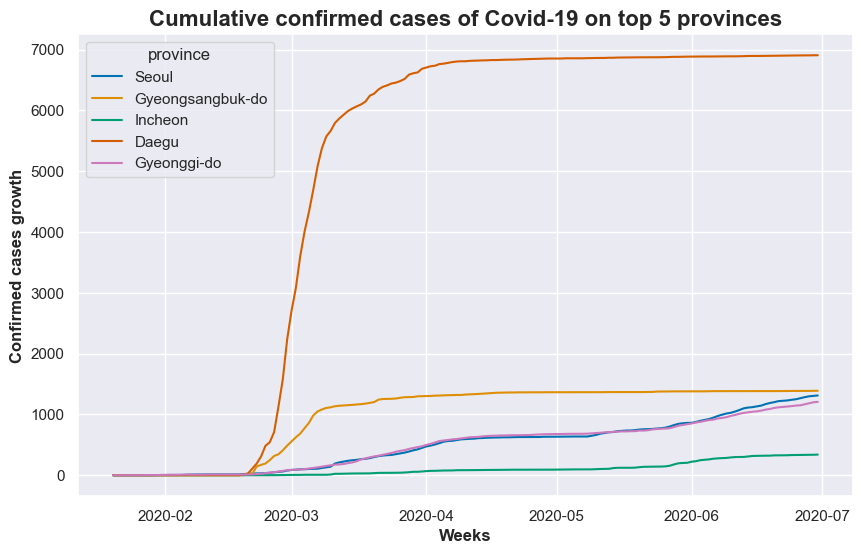

In [281]:
sns.set_style("darkgrid")
sns.set_context("notebook")
fig, ax = plt.subplots(figsize=(10, 6))
sns.lineplot(
    data=top_five_df,
    x="date",
    y=top_five_df["confirmed_cumsum"],
    hue="province",
    palette="colorblind",
)

plt.xlabel("Weeks", fontweight="bold")
plt.ylabel("Confirmed cases growth", fontweight="bold")
plt.title(
    "Cumulative confirmed cases of Covid-19 on top 5 provinces",
    fontweight="bold",
    fontsize=16,
)

plt.show()

Despite the fact that all of the provinces confirmed cases started to grow almost the same  
time, it can be clearly seen that Daegu and Gyeongsangbuk-do provinces  
differs from others with it's high confirmed cases.

To see pandemic spots more clear, South Korea's map  
was plotted where higher radius means higher  
confirmed cases number.

In [282]:
inf_locations = clean_case.copy()
inf_locations = inf_locations.loc[inf_locations["latitude"] != "-"]
inf_locations.reset_index(drop=True, inplace=True)
inf_locations[["latitude", "longitude"]] = inf_locations[
    ["latitude", "longitude"]
].astype(float)
inf_locations.head(3)

,case_id,province,city,group,infection_case,confirmed,latitude,longitude
0,1000001,Seoul,Yongsan-gu,True,Itaewon Clubs,139,37.538621,126.992652
1,1000002,Seoul,Gwanak-gu,True,Richway,119,37.482080,126.901384
2,1000003,Seoul,Guro-gu,True,Guro-gu Call Center,95,37.508163,126.884387


In [283]:
import folium
import math

map_obj = folium.Map(
    location=[36.82902069828695, 127.06787109375001],
    zoom_start=7,
    tiles="CartoDB positron",
)

for city in inf_locations.itertuples():
    local_deformation = math.cos(city.latitude * math.pi / 180)
    folium.CircleMarker(
        location=[city.latitude, city.longitude],
        popup="%s (%.1f)" % (city.city, city.confirmed),
        radius=city.confirmed / 35,
        color="crimson",
        fill=True,
        fill_color="crimson",
    ).add_to(map_obj)
map_obj.get_root().html.add_child(
    folium.Element("<h3 align='center'>South Korea's pandemic spots</h3>")
)
map_obj

Samely as plottet graph above, Daegu has the highest spot  
which means the strongest pandemic epicenter.  
Red spots also indicates places that should be avoided.

Daegu and Gyeongsangbuk-do provinces results led to further investigation.  
Confirmed cases to population regression was created for all provinces  
to check if cases growth increases with higher people population.

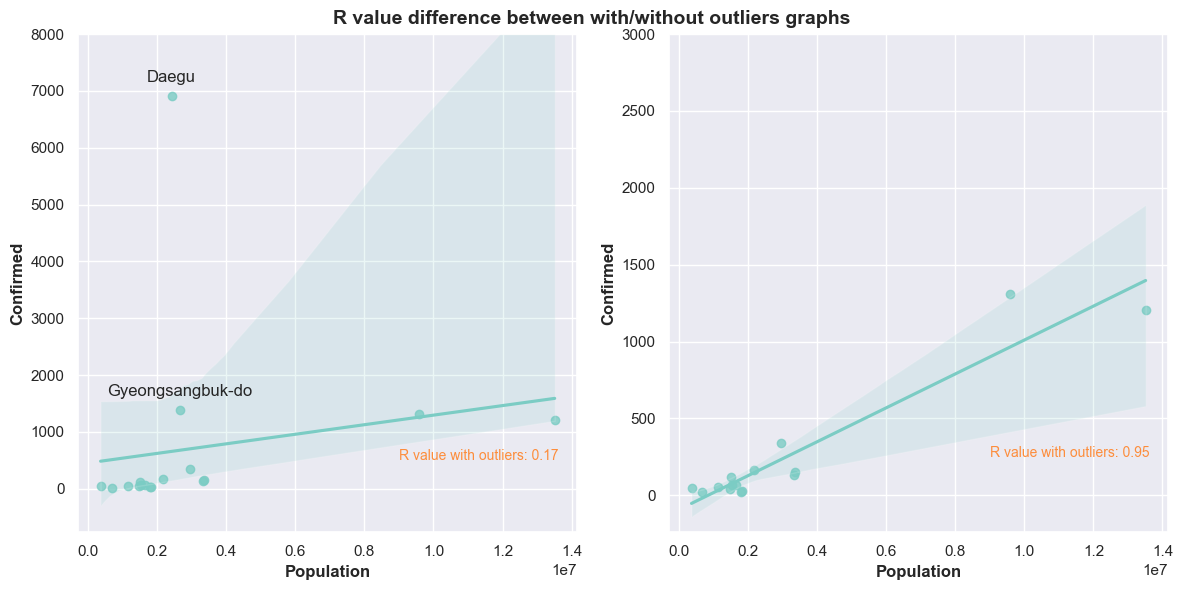

In [284]:
provpop = provpop_merged.copy()
del provpop["province"]
prov1 = provpop.loc[provpop["confirmed"] == 6906]
prov2 = provpop.loc[provpop["confirmed"] == 1389]
no_outliers = provpop.drop(
    provpop[(provpop["confirmed"] == 6906) | (provpop["confirmed"] == 1389)].index
)
slope, intercept, r_value, p_value, std_err = stats.linregress(
    provpop["population"], provpop["confirmed"]
)
slope1, intercept1, r_value1, p_value1, std_err1 = stats.linregress(
    no_outliers["population"], no_outliers["confirmed"]
)

fig, ax = plt.subplots(1, 2, figsize=(12, 6))

sns.regplot(data=provpop, x="population", y="confirmed", color="#7bccc4", ax=ax[0])
ax[0].set_ylim(None, 8000)
ax[0].annotate(
    "Daegu",
    (prov1["population"].iloc[0], prov1["confirmed"].iloc[0]),
    xytext=(0, 10),
    textcoords="offset points",
    ha="center",
)
ax[0].annotate(
    "Gyeongsangbuk-do",
    (prov2["population"].iloc[0], prov2["confirmed"].iloc[0]),
    xytext=(0, 10),
    textcoords="offset points",
    ha="center",
)
ax[0].set_xlabel("Population", fontweight="bold")
ax[0].set_ylabel("Confirmed", fontweight="bold")

sns.regplot(data=no_outliers, x="population", y="confirmed", color="#7bccc4", ax=ax[1])
ax[1].set_ylim(None, 3000)
ax[1].set_xlabel("Population", fontweight="bold")
ax[1].set_ylabel("Confirmed", fontweight="bold")

plt.tight_layout()
plt.subplots_adjust(top=0.94)
text1 = f"R value with outliers: {r_value:.2f}"
text2 = f"R value with outliers: {r_value1:.2f}"
ax[0].text(9000000, 500, text1, fontsize=10, color="#fd8d3c")
ax[1].text(9000000, 250, text2, fontsize=10, color="#fd8d3c")
fig.suptitle(
    "R value difference between with/without outliers graphs",
    size=14,
    fontweight="bold",
    ha="center",
)

plt.show()

On the left plot dependency of "Confirmed" to "Population", is low as it  
can be seen on low R value (R=0.17). On the first sight it could be said, that in higher populated places  
confirmed cases does not grow faster. But this regression's results might be inaccurate due to  
two outliers which are Daegu and Gyeongsangbuk-do. By excluding these, we get very  
high dependency with R value 0.95 and it can be said that with higher populated places  
virus spread faster with more confirmed cases.  
Also, there is something about these two outliers which will be explained  
in further investigation.

### Region analysis

Daegu and Gyeongsangbuk-do is highly but not the highest populated  
areas. So why they have highest confirmed cases growth? Trying to  
answer this question, count of institutions per province was plotted.

In [285]:
clean_region_top = clean_region[
    ["province", "elementary_school_count", "university_count", "nursing_home_count"]
]
clean_region_top = clean_region_top[clean_region_top["province"].isin(top_names)]
clean_region_top

,province,elementary_school_count,university_count,nursing_home_count
0,Seoul,607,48,22739
1,Seoul,33,0,3088
2,Seoul,27,0,1023
3,Seoul,14,0,628
4,Seoul,36,1,1080
...,...,...,...,...
218,Gyeongsangbuk-do,16,0,108
219,Gyeongsangbuk-do,11,0,85
220,Gyeongsangbuk-do,8,0,55
221,Gyeongsangbuk-do,21,2,151


In [286]:
group_region = clean_region_top.groupby("province").agg(
    {"elementary_school_count": "sum", "university_count": "sum"}
)
group_region

,elementary_school_count,university_count
province,,
Daegu,458,22
Gyeonggi-do,2554,122
Gyeongsangbuk-do,942,66
Incheon,500,14
Seoul,1214,96


<Figure size 800x600 with 0 Axes>

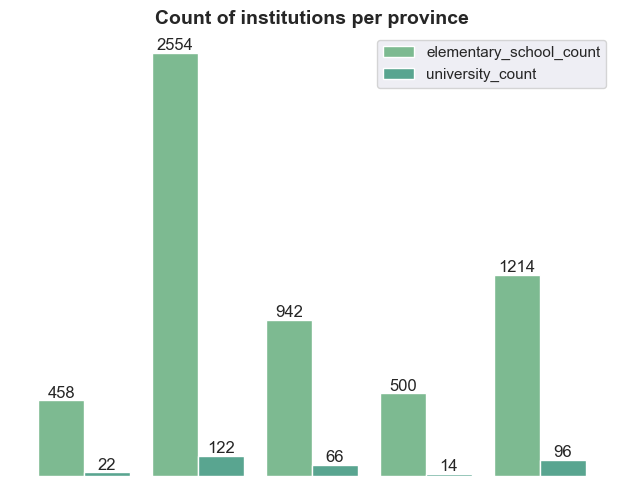

In [287]:
plt.figure(figsize=(8, 6))

sns.set_palette("crest")
ax = group_region.plot(kind="bar", width=0.8)

for container in ax.containers:
    ax.bar_label(container)
ax.axes.get_yaxis().set_visible(False)
ax.axes.get_xaxis().set_visible(False)
ax.set_frame_on(False)
plt.xticks(rotation=45)
plt.tight_layout()
plt.title("Count of institutions per province", size=14, fontweight="bold", ha="center")

plt.show()

It can be seen from plot, that Daegu and Gyeongsangbuk-do do not  
have more elementary schools or universities than other provinces.  
So, this does not answers question, why?

### Case analysis

In [288]:
infected_in_group = clean_case["group"].value_counts(normalize=True)

print("Percentage of infected in group:", round(infected_in_group[True] * 100, 2))
print("Percentage of infected not in group:", round(infected_in_group[False] * 100, 2))

Percentage of infected in group: 71.26
Percentage of infected not in group: 28.74


In [289]:
clean_case = clean_case.sort_values(by="confirmed", ascending=False)
clean_case.head(3)

,case_id,province,city,group,infection_case,confirmed,latitude,longitude
48,1200001,Daegu,Nam-gu,True,Shincheonji Church,4511,35.84008,128.5667
56,1200009,Daegu,-,False,contact with patient,917,-,-
57,1200010,Daegu,-,False,etc,747,-,-


In [290]:
church = clean_case[clean_case["infection_case"] == "Shincheonji Church"]
church = (
    church.groupby("province")
    .agg({"confirmed": "sum"})
    .sort_values(by="confirmed", ascending=False)
)
church.iloc[:5]

,confirmed
province,
Daegu,4511
Gyeongsangbuk-do,566
Gyeongsangnam-do,32
Gyeonggi-do,29
Gangwon-do,17


- Most impact for high infections increase gave crowded places, aspecially Shincheonji Church.  
- People tend to visit it due to religious beliefs despite the posibility to get infected.  
- This creates perfect place for virus to spread.  
- Contact with patient is second problem, which is hard to solve due to patient needs of care.

In [291]:
church_nochurch = clean_case.copy()
shincheonji = church_nochurch.copy()
church_nochurch.loc[
    church_nochurch["infection_case"] != "Shincheonji Church", "infection_case"
] = "other"
church_nochurch = (
    church_nochurch.groupby("infection_case").agg({"confirmed": "sum"}).reset_index()
)
shincheonji = shincheonji[shincheonji["infection_case"] == "Shincheonji Church"]
shincheonji.loc[
    ~shincheonji["province"].isin(["Daegu", "Gyeongsangbuk-do"]), "province"
] = "other_provinces"
shincheonji = (
    shincheonji.groupby("province")
    .agg({"confirmed": "sum"})
    .sort_values(by="confirmed", ascending=False)
    .reset_index()
)

print(church_nochurch)
print(shincheonji)

       infection_case  confirmed
0  Shincheonji Church       5213
1               other       6182
           province  confirmed
0             Daegu       4511
1  Gyeongsangbuk-do        566
2   other_provinces        136


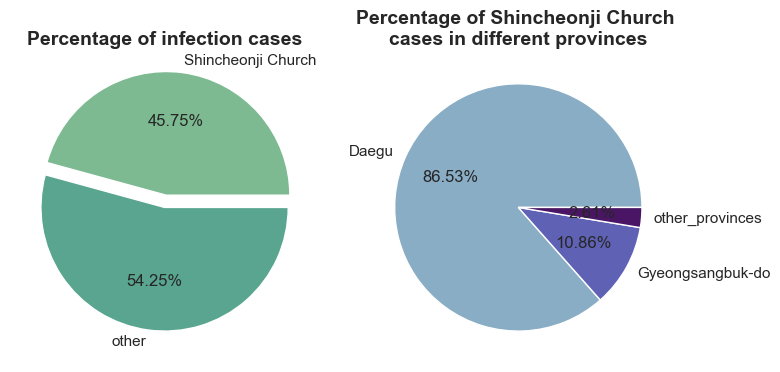

In [292]:
fig, ax = plt.subplots(1, 2, figsize=(8, 5))
explode = [
    0.1 if val == "Shincheonji Church" else 0
    for val in church_nochurch["infection_case"]
]

ax[0].pie(
    church_nochurch["confirmed"],
    labels=church_nochurch["infection_case"],
    explode=explode,
    autopct="%.2f%%",
    colors=sns.color_palette("crest"),
)
ax[0].set_title(
    "Percentage of infection cases", size=14, fontweight="bold", ha="center"
)

ax[1].pie(
    shincheonji["confirmed"],
    labels=shincheonji["province"],
    autopct="%.2f%%",
    colors=sns.color_palette("twilight"),
)
ax[1].set_title(
    "Percentage of Shincheonji Church \ncases in different provinces",
    size=14,
    fontweight="bold",
    ha="center",
)
plt.tight_layout()

plt.show()

- From case data analysis it can be seen, that almost  
half of the cases happened with Shincheonji Church.  
- On the right side plot same church case on different provinces are shown.  
- Daegu and Gyeongsangbuk-do are the main provinces of this case.  
- It can be said, that Shincheonji Church case is the main reason  
of high rate confirmed cases in Daegu and Gyeongsangbuk-do.  
- And because Daegu is the capital of Gyeongsangbuk-do it is logical  
percentage.  
- Getting more in details, there was a 61 year old woman, who attended to Shincheonji  
Church in Daegu and spreaded virus. This church became an epicenter of Covid.  
Link to article: https://foreignpolicy.com/2020/08/19/south-korea-coronavirus-scapegoat-shincheonji/

### Covid-19 tests

Correlation of various cases

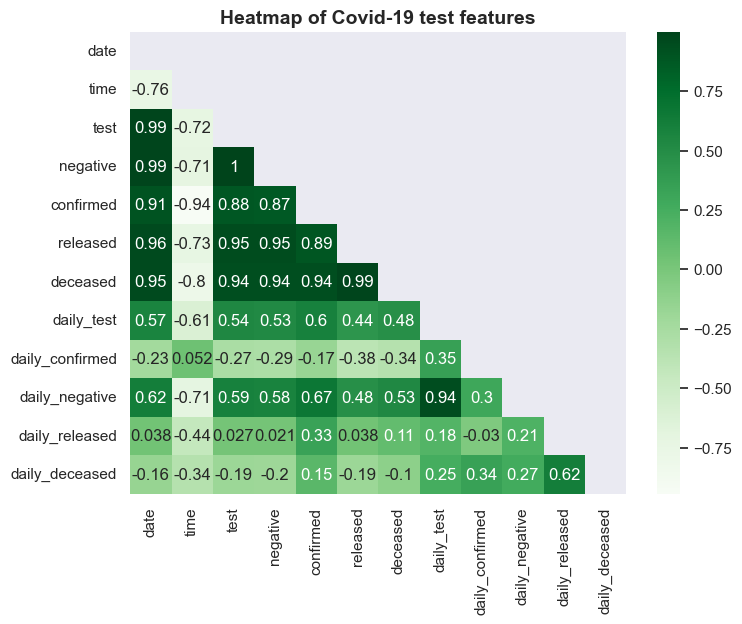

In [297]:
mask = np.triu(np.ones_like(clean_time.corr()))
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(clean_time.corr(), annot=True, mask=mask, cmap="Greens")
plt.grid(False)

ax.set_title(
    "Heatmap of Covid-19 test features",
    size=14,
    fontweight="bold",
    ha="center"
)

plt.show()

Strong correlation between date and negative tests  
can be seen which means that with each day negative  
tests occurs more often as well as tests numbers increases.

New columns created with daily results by using  
.diff() function

In [198]:
clean_time["daily_test"] = clean_time["test"].diff()
clean_time["daily_confirmed"] = clean_time["confirmed"].diff()
clean_time["daily_negative"] = clean_time["negative"].diff()
clean_time["daily_released"] = clean_time["released"].diff()
clean_time["daily_deceased"] = clean_time["deceased"].diff()

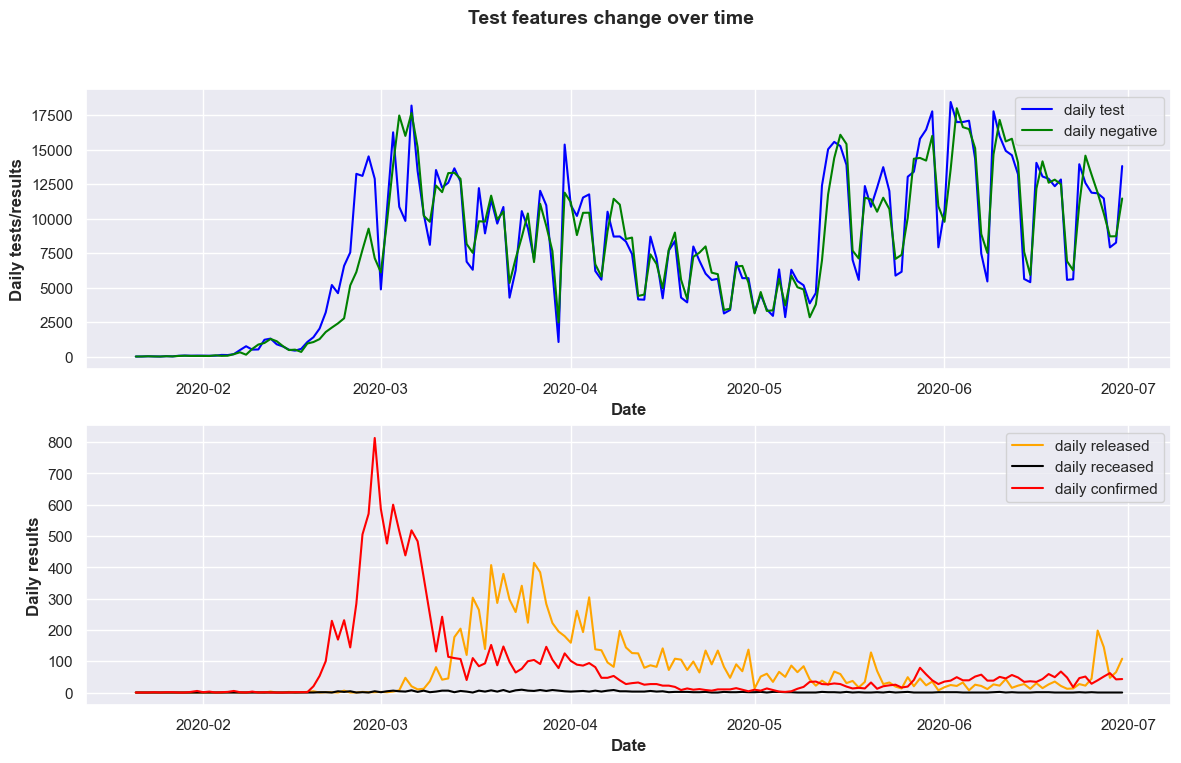

In [298]:
fig, ax = plt.subplots(2, 1, figsize=(14, 8))

sns.lineplot(
    data=clean_time,
    x="date",
    y="daily_test",
    label="daily test",
    color="blue",
    ax=ax[0],
)
sns.lineplot(
    data=clean_time,
    x="date",
    y="daily_negative",
    label="daily negative",
    color="green",
    ax=ax[0],
)
ax[0].set_xlabel("Date", fontweight="bold")
ax[0].set_ylabel("Daily tests/results", fontweight="bold")

sns.lineplot(
    data=clean_time,
    x="date",
    y="daily_released",
    label="daily released",
    color="orange",
    ax=ax[1],
)
sns.lineplot(
    data=clean_time,
    x="date",
    y="daily_deceased",
    label="daily receased",
    color="black",
    ax=ax[1],
)
sns.lineplot(
    data=clean_time,
    x="date",
    y="daily_confirmed",
    label="daily confirmed",
    color="red",
    ax=ax[1],
)
ax[1].set_xlabel("Date", fontweight="bold")
ax[1].set_ylabel("Daily results", fontweight="bold")

fig.suptitle("Test features change over time", size=14, fontweight="bold", ha="center")

plt.show()

- Daily tests had two peaks over half year which was on  
a March and June;  
- Daily negative test line was almost always lower but  
very similar in shape;  
- In second plot, daily confirmed tests reached it's peak on March  
while daily released peak started nearly 14 days after. It is logical  
because this is the interval of being ill with Covid-19;  
- Daily deceased line is just above 0 but still it exists and it's peak  
is similar to "daily released", 14 days after virus was confirmed.

### TimeAge spreading

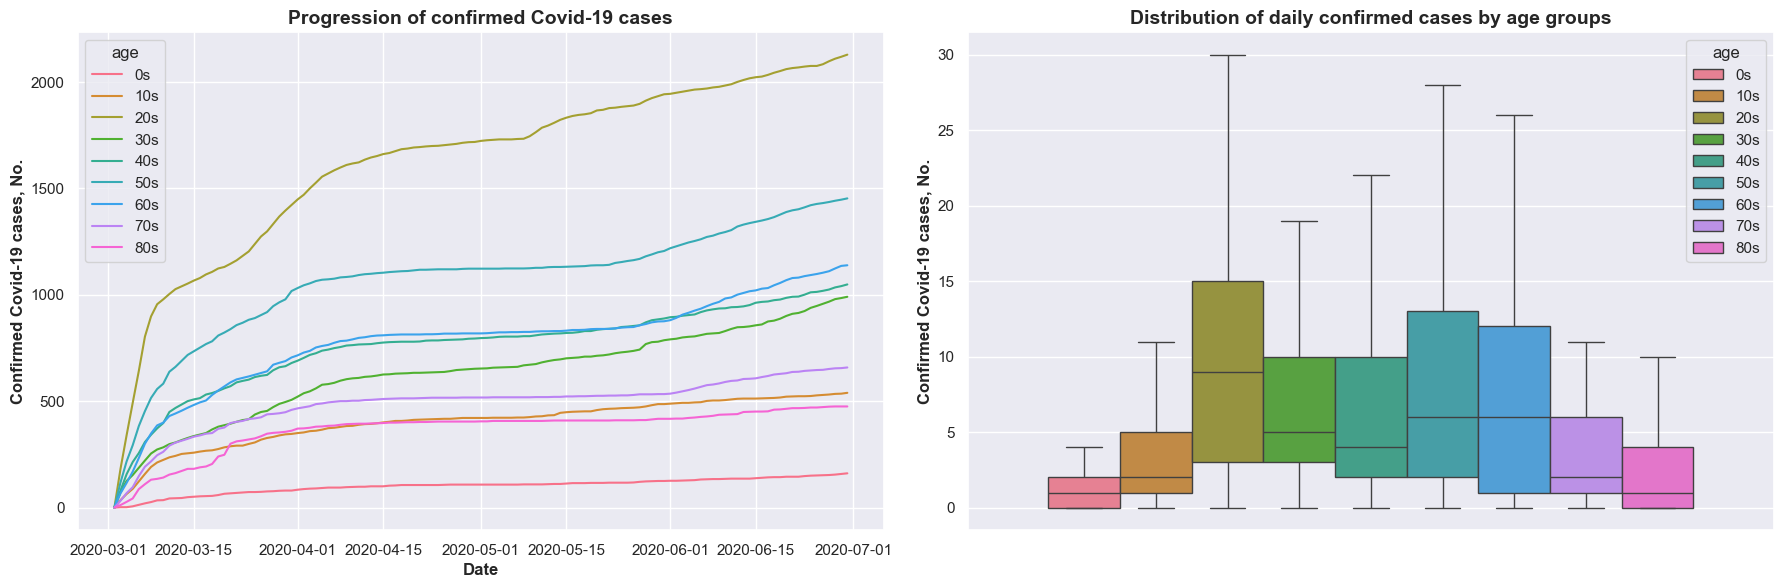

In [299]:
sns.set_style("darkgrid")
sns.set_context("notebook")
fig, ax = plt.subplots(1, 2, figsize=(18, 6))

sns.lineplot(data=clean_time_age, x="date", y="confirmed_cumsum", hue="age", ax=ax[0])
ax[0].set_xlabel("Date", fontweight="bold")
ax[0].set_ylabel("Confirmed Covid-19 cases, No.", fontweight="bold")
ax[0].set_title(
    "Progression of confirmed Covid-19 cases", size=14, fontweight="bold", ha="center"
)

sns.boxplot(
    data=clean_time_age,
    y="daily_confirmed",
    hue="age",
    ax=ax[1],
    showfliers=False,
    flierprops=dict(markerfacecolor="red", marker="o"),
)
ax[1].set_ylabel("Confirmed Covid-19 cases, No.", fontweight="bold")
ax[1].set_title(
    "Distribution of daily confirmed cases by age groups",
    size=14,
    fontweight="bold",
    ha="center",
)

plt.tight_layout()
plt.subplots_adjust(top=0.94)

plt.show()

- The most progressive increase of confirmed cases each day  
has 20s age group;  
- Same group has the highest distribution of confirmed cases per day;  
- Strangely, second highest is the 50s group.

Grouped by age and Case Fatality Rate (CFR) calculated for each group

In [300]:
grouped_age = clean_time_age.groupby("age").agg({"confirmed": "max", "deceased": "max"})
grouped_age["cfr"] = round(
    (grouped_age["deceased"] / grouped_age["confirmed"]) * 100, 2
)
grouped_age

,confirmed,deceased,cfr
age,,,
0s,193,0,0.00
10s,708,0,0.00
20s,3362,0,0.00
30s,1496,2,0.13
40s,1681,3,0.18
50s,2286,15,0.66
60s,1668,41,2.46
70s,850,82,9.65
80s,556,139,25.00


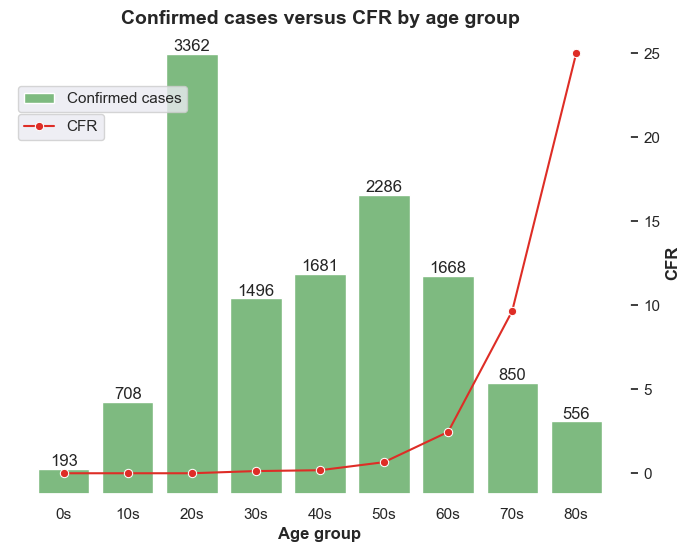

In [301]:
fig, ax = plt.subplots(figsize=(8, 6))

splot = sns.barplot(
    data=grouped_age, x="age", y="confirmed", label="Confirmed cases", color="#74c476"
)

for container in ax.containers:
    ax.bar_label(container)
ax.set_yticks([])
ax.set_ylabel(None)
ax.set_xlabel("Age group", fontweight="bold")
ax.set_frame_on(False)

ax2 = ax.twinx()

sns.lineplot(
    data=grouped_age, x="age", y="cfr", label="CFR", color="#de2d26", marker="o", ax=ax2
)
ax2.grid(False)
ax2.set_ylabel("CFR", fontweight="bold")

plt.title(
    "Confirmed cases versus CFR by age group", size=14, fontweight="bold", ha="center"
)
ax.legend(loc="upper left", bbox_to_anchor=(0, 0.90))
ax2.legend(loc="upper left", bbox_to_anchor=(0, 0.84))

plt.show()

- Low CFR in younger age groups. 0 to 20s have 0 reported deaths;  
This allows understanding that younger age individuals are less  
severely affected by covid19;  
- CFR tends to increase with age. Higher the age, higher CFR. Older individuals  
are more vulnerable to deceases;  
- 80s age group has the highest confirmed to deceased ratio indicating as  
the highest risk group;  
- Highest impact of confirmed cases has 20s group.

### TimeGender spreading

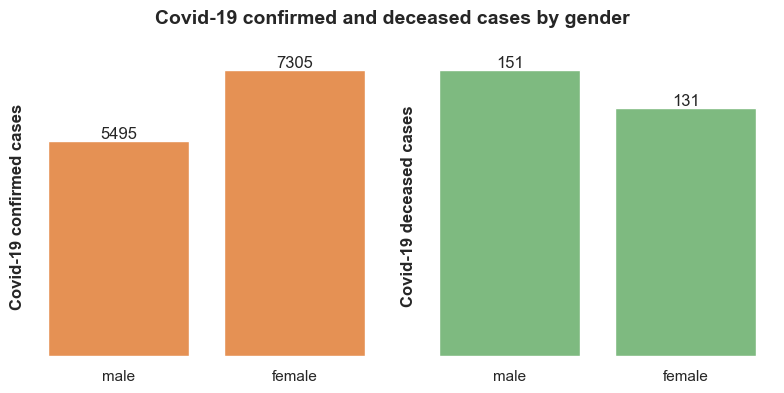

In [302]:
sns.set_style("darkgrid")
sns.set_context("notebook")
fig, ax = plt.subplots(1, 2, figsize=(8, 4))

sns.barplot(
    data=clean_time_gender,
    x="sex",
    y="confirmed",
    ax=ax[0],
    color="#fd8d3c",
    errorbar=None,
    estimator=max,
)
for container in ax[0].containers:
    ax[0].bar_label(container)
ax[0].set_xlabel(None)
ax[0].set_ylabel("Covid-19 confirmed cases", fontweight="bold")
ax[0].set_frame_on(False)
ax[0].set_yticks([])

sns.barplot(
    data=clean_time_gender,
    x="sex",
    y="deceased",
    ax=ax[1],
    color="#74c476",
    errorbar=None,
    estimator=max,
)
for container in ax[1].containers:
    ax[1].bar_label(container)
ax[1].set_xlabel(None)
ax[1].set_ylabel("Covid-19 deceased cases", fontweight="bold")
ax[1].set_frame_on(False)
ax[1].set_yticks([])

fig.suptitle(
    "Covid-19 confirmed and deceased cases by gender",
    size=14,
    fontweight="bold",
    ha="center",
)
plt.tight_layout()

plt.show()

In [303]:
grouped_gender = clean_time_gender.groupby("sex").agg(
    {"confirmed": "max", "deceased": "max"}
)
grouped_gender.loc["total"] = {
    "confirmed": grouped_gender["confirmed"].sum(),
    "deceased": grouped_gender["deceased"].sum(),
}
grouped_gender["cfr"] = round(
    (grouped_gender["deceased"] / grouped_gender["confirmed"]) * 100, 2
)
grouped_gender

,confirmed,deceased,cfr
sex,,,
female,7305,131,1.79
male,5495,151,2.75
total,12800,282,2.20


In [304]:
total_confirmed = grouped_gender["confirmed"].loc["total"]
total_deceased = grouped_gender["deceased"].loc["total"]
cfr = grouped_gender["cfr"].loc["total"]
cfr_male = grouped_gender["cfr"].loc["male"]
cfr_female = grouped_gender["cfr"].loc["female"]

print(f"Total confirmed cases in period 2020-01 -- 2020-07 is: {total_confirmed}")
print(f"Total deceased cases in the same period is: {total_deceased}")
print(f"Total case fatality ratio (CFR) is: {cfr}%")
print(f"CFR male/female comparison: male({cfr_male}%) > female({cfr_female}%)")

Total confirmed cases in period 2020-01 -- 2020-07 is: 12800
Total deceased cases in the same period is: 282
Total case fatality ratio (CFR) is: 2.2%
CFR male/female comparison: male(2.75%) > female(1.79%)


## Summary

- Based on a given data, virus spread had two major waves 2020-03  
and 2020-06;  
- The most confirmed cases was in Daegu province with deceased  
cases as well. Despite the mentioned fact, Daegu isn't the most  
populated city;  
- Main infection case that resulted high confirmed case numbers  
of Daegu city was Shincheonji Church event where virus has been  
spreaded strongly by religious people;  
- With increased virus spread, test number also increased;  
- Daily confirmed cases peak was on 2020-03 with the following daily  
released peak after 14 days which correlates with ill interval;  
- The most progressive increase of confirmed cases each day  
has 20s age group. Same group has the highest distribution of confirmed cases  
per day. This might be due to active life, university studies and overall  
tendency to break the rules of 20s group.  
- Despite 20s high confirmed cases per day rate, Case Fatality Rate (CFR) is very  
low which means that this group is more virus carriers/spreaders than risk group;  
- With year increase CFR also increases. That means that 80s are at the highest  
group to decease;  
- Interesting results is confirmed cases by gender. Females are tend to get  
a virus more (>30%) but their decease rate is lower than males.